# AI Gatekeeper Evaluation: Scaled Features

Notebook ini menambahkan langkah **Normalisasi/Standardisasi** pada fitur sebelum melatih model.

## 🎯 Tujuan:
- Menerapkan `StandardScaler` untuk menormalisasi fitur (Mean=0, Std=1).
- Mengevaluasi apakah penskalaan fitur meningkatkan performa Random Forest.

## 🛠 Perubahan:
- Menambahkan **StandardScaler** pada tahap preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## 1. Data Loading & Feature Engineering

In [2]:
# Load Data
file_path = 'dataset_2023_2025.xlsx'
try:
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
    print(f"📊 Loaded {len(data)} rows of data")
except FileNotFoundError:
    print(f"❌ Error: File '{file_path}' not found.")

# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Create features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Binary labeling
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

print("Feature shape:", features.shape)

📊 Loaded 990 rows of data
Feature shape: (927, 4)


## 2. Train/Test Split & Scaling

In [3]:
# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train_raw = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
y_train = features.loc[train_mask, 'Target']
X_test_raw = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
y_test = features.loc[test_mask, 'Target']

print(f"Training set: {len(X_train_raw)} samples")
print(f"Testing set: {len(X_test_raw)} samples")

# A. Normalisasi/Standardisasi
print("\n🔄 Applying StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert back to DataFrame for easier handling (optional but good for maintaining column names)
X_train = pd.DataFrame(X_train_scaled, index=X_train_raw.index, columns=X_train_raw.columns)
X_test = pd.DataFrame(X_test_scaled, index=X_test_raw.index, columns=X_test_raw.columns)

print("✅ Features scaled successfully!")
print("Train Mean:\n", X_train.mean().round(4))
print("Train Std:\n", X_train.std().round(4))

Training set: 562 samples
Testing set: 365 samples

🔄 Applying StandardScaler...
✅ Features scaled successfully!
Train Mean:
 Vol_20    0.0
Mom_20    0.0
Mom_50    0.0
dtype: float64
Train Std:
 Vol_20    1.0009
Mom_20    1.0009
Mom_50    1.0009
dtype: float64


## 3. Train Model (Scaled Features)

In [4]:
# Train Optimized Random Forest
print("🔄 Training Random Forest on SCALED features...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Model trained successfully!")

🔄 Training Random Forest on SCALED features...
✅ Model trained successfully!


## 4. Evaluation

In [5]:
# Calculate metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"{dataset_name} Performance")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}

train_metrics = calculate_metrics(y_train, y_train_pred, "TRAINING SET (Scaled)")
test_metrics = calculate_metrics(y_test, y_test_pred, "TESTING SET (Scaled)")

roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=['Bearish', 'Bullish']))


TRAINING SET (Scaled) Performance
Accuracy:  0.7011 (70.11%)
Precision: 0.6782
Recall:    0.8782
F1-Score:  0.7654

TESTING SET (Scaled) Performance
Accuracy:  0.4904 (49.04%)
Precision: 0.5201
Recall:    0.7828
F1-Score:  0.6250

ROC-AUC Score: 0.4686

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

     Bearish       0.36      0.14      0.21       167
     Bullish       0.52      0.78      0.62       198

    accuracy                           0.49       365
   macro avg       0.44      0.46      0.42       365
weighted avg       0.45      0.49      0.43       365



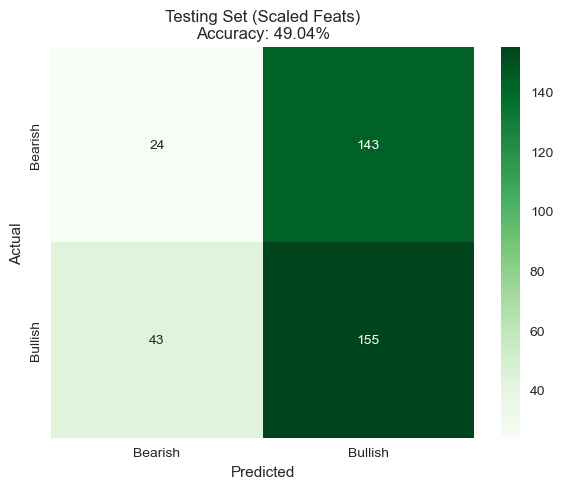

In [6]:
# Confusion matrices
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'])
plt.title(f'Testing Set (Scaled Feats)\nAccuracy: {test_metrics["Accuracy"]:.2%}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('scaled_confusion_matrix.png')
plt.show()